**1) ReAct-агент на LangChain:**

Реализованный ниже агент представляет собой советника для туристов, помогающего им находить интересные места (напр., кафе, рестораны, достопримечательности, торговые центры и т.п.) по заданному адресу. Агент построен по принципу ReAct: он не только генерирует ответы, но и самостоятельно принимает решения о необходимости использования имеющихся у него инструментов.

В качестве инструмента агент использует поисковик DuckDuckGo, который позволяет ему получать актуальную информацию из Интернета. При получении пользовательского запроса агент анализирует его и выделяет ключевые слова (тип интересующего объекта и географическую локацию), а затем формирует поисковый запрос и обращается к инструменту.

На каждом шаге агент либо принимает решение вызвать инструмент, либо, если считает, что имеющейся информации досточно, формирует ответ. Результаты работы инструментов сохраняются в "scratchpad" и используются для дальнейших рассуждений. Кроме того, агент обладает памятью, что позволяет учитывать предыдущие сообщения пользователя. Использованные мною в качестве примеров вопросы подтверждают наличие у агента памяти: в первом случае я предоставила ему информацию и о типе объекта, и о местоположении, а во втором - попросила найти другой тип объекта по этому же адресу, с чем агент успешно справился - он не стал задавать уточняющие вопросы и сразу понял, о какой улице я его спрашиваю.

Итогом работы агента является ответ на интересующий пользователя вопрос - подборка релевантных мест с небольшими описаниями. Таким образом, агент автоматизирует процесс поиска и анализа информации, упрощая планирование досуга или путешествия.



In [1]:
!pip install -qU langchain==0.3.25 langchain-core==0.3.65 langchain-community==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 langgraph==0.2.35

In [2]:
OPENROUTER_TOKEN = "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"

In [3]:
from langchain_openai import ChatOpenAI

#импортируем модель с тулзами
llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    #model = "stepfun/step-3.5-flash:free"
    model = "qwen/qwen3.6-plus-preview:free"
)

response = llm.invoke("Привет! Как твои дела?").content
print(response)

Привет! У меня всё отлично, спасибо, что спросил! 😊 Я всегда готов помочь.

А как твои дела? Чем могу быть полезен сегодня?


**Источник:**

https://openrouter.ai/models?fmt=cards&input_modalities=text&max_price=0&output_modalities=text&supported_parameters=tools&order=most-popular

In [4]:
!pip install ddgs

In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

from ddgs import DDGS

#создаем инструмент-поисковик
@tool #декоратор
def web_search(request: str) -> str:
    """Используй этот инструмент для поиска информации в Интернете через DuckDuckGo.

    Запрос должен быть коротким (до ~5 слов) и содержать тип объекта и локацию.

    Примеры:
        "рестораны на улице Арбат"
        "поликлиники в ЮВАО"
        "булочные в Санкт-Петербурге"
    """

    with DDGS() as ddgs:
        results = ddgs.text(
            request.strip(),
            region="ru-ru",
            safesearch="moderate",
            timelimit=None,
            max_results=7
        )

    formatted_results = []

    for r in results:
        title = r.get("title", "")
        url = r.get("href", "")
        body = r.get("body", "")

        formatted_results.append(f"{title}\n{url}\n{body}")

    return "\n\n".join(formatted_results)

tools = [web_search]

**Источник:**

https://pypi.org/project/duckduckgo-search/

In [6]:
from langchain.memory import ConversationBufferMemory #память

memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

/tmp/ipykernel_22864/1697820259.py:3: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

#создаем промпт к истории сообщений
history_analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Проанализируй историю диалога ниже и выяви любые поисковые операции в Интернете, которые уже были выполнены. "
        "Извлеки результаты этих поисковых операций, чтобы их можно было повторно использовать вместо нового поиска в Интернете."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "Какие поисковые операции были выполнены и каковы их результаты?"),
])

#создаем промпт для агента
agent_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Ты — полезный ассистент. Отвечая на вопрос пользователя, "
        "ты можешь использовать инструмент google_search. "
        "Если не знаешь ответ — используй tools,"
        "если информации достаточно — сразу отвечай пользователю. "
        "Постарайся не сильно сомневаться в информации, которую ты "
        "находишь в Интернете — достаточно проверить её всего пару раз. "
        "ВАЖНО: используй анализ предыдущих поисковых запросов, чтобы "
        "избегать повторного поиска в Интернете."
    )),
    ("human", "Анализ предыдущих поисковых запросов: {history_analysis}"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

In [8]:
#задаем агента с памятью
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | {
        "history_analysis": lambda x: llm.invoke(history_analysis_prompt.format_messages(
            chat_history=x["chat_history"]
        )).content,
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | agent_prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

In [9]:
name2tool = {tool.name: tool.func for tool in tools}

class CustomAgentExecutor:
    def __init__(self, max_iterations: int = 5):
        self.max_iterations = max_iterations #задаем количество итераций (максимальное количество шагов агента)
        self.chat_history = [] #память диалога
        self.agent = agent

    def invoke(self, input: str) -> dict: #запуск агента (запрос --> ответ)
        agent_scratchpad = [] #память рассуждений агента
        final_answer = None

        for step in range(self.max_iterations):
            tool_call = self.agent.invoke({ #вызов модели
                "input": input,
                "chat_history": self.chat_history,
                "agent_scratchpad": agent_scratchpad
            })

            #сохраняем шаги
            agent_scratchpad.append(tool_call)

            if tool_call.tool_calls: #если модель хочет вызвать инструмент
                for tool_call_obj in tool_call.tool_calls:
                    tool_name = tool_call_obj["name"]
                    tool_args = tool_call_obj["args"]

                    #вызов инструмента
                    tool_out = name2tool[tool_name](**tool_args)

                    #сохраняем результаты применения инструментов
                    agent_scratchpad.append(
                        ToolMessage(
                            content = tool_out,
                            tool_call_id = tool_call_obj["id"]
                        )
                    )
                continue #даем модели возможность продолжения размышлений

            final_answer = tool_call.content #окончание размышлений
            break

        if final_answer is None:
            final_answer = "Не удалось сформировать ответ"

        #сохраняем запросы пользователя и ответы модели
        self.chat_history.extend([
            HumanMessage(content=input),
            AIMessage(content=final_answer)
        ])

        return {"output": final_answer}

conversational_agent = CustomAgentExecutor()

In [10]:
#первый вопрос

result = conversational_agent.invoke("Посоветуй мне кафе на улице Мясницкая (Москва), куда можно сходить с друзьями.")
print(f"Результат: {result['output']}")

Результат: Для встречи с друзьями на Мясницкой улице есть несколько отличных вариантов, которые подойдут для шумных компаний, вкусной еды и хорошей атмосферы:

🍔 **Steak it easy** (Мясницкая ул., 7, стр. 1)
Отличный сетевой стейк-хаус от холдинга братьев Васильчуков.
*   **Атмосфера:** Расслабленная, современная.
*   **Кухня:** Качественные стейки, бургеры и хорошие винные коктейли.
*   **Для кого:** Идеально для мужской компании или тех, кто хочет сытно и вкусно поесть мяса.
*   **Цены:** Средний счет ориентировочно 1000–1500 руб.

🥟 **Вареничная №1** (Мясницкая ул., 24)
Уютное место с интерьером в советском стиле.
*   **Атмосфера:** «Вкусно, как у бабушки», ностальгическая.
*   **Кухня:** Огромный выбор вареников (с картошкой, вишней, мясом), пельмени, салаты.
*   **Для кого:** Хороший демократичный вариант, если хочется вкусной домашней еды в теплой обстановке.

🍹 **Бары на Мясницкой, 30/1/2** (например, Безвизовый режим / Poesia Cafe Bar)
Здесь находятся несколько популярных заведе

In [11]:
#второй вопрос

result = conversational_agent.invoke("А теперь посоветуй мне рестораны на этой же улице.")
print(f"Результат: {result['output']}")

Результат: На Мясницкой улице и в непосредственной близости (в пределах пары зданий) есть несколько отличных вариантов с совершенно разной атмосферой. Вот свежие рекомендации на основе найденного:

1.  **Brasserie Lambic** (Мясницкая ул., 40)
    *   *Кухня:* Европейская, бельгийская.
    *   *Атмосфера:* Живой, шумный ресторан-пивоварня. Здесь подают отличные стейки, морепродукты и большое количество крафтового и классического пива (в том числе собственного производства).
    *   *Для кого:* Идеально для встреч с друзьями, бизнес-ланчей и ужина в расслабленной обстановке.

2.  **J'PAN** (Мясницкая ул., 22/1/7)
    *   *Кухня:* Паназиатская (суши, воки, паназиатские сеты).
    *   *Атмосфера:* Стильное, современное место с модным интерьером. Часто бывает плотно, лучше бронировать заранее.
    *   *Для кого:* Подойдет для свиданий или встреч с компанией, где любят азиатскую еду и коктейли.

3.  **IZUMI**
    *   *Кухня:* Японская (высокий уровень).
    *   *Атмосфера:* Более ресторанный

**2) Агент на LangGraph:**

Второй агент также представляет собой помощника для туристов, но на этот раз - позволяющего оперативно получать информацию о погоде в интересующем их городе: как текущую, так и прогноз на следующий день. Агент реализован с использованием LangGraph, что позволяет представить его работу как последовательность шагов (узлов графа).

Сначала агент анализирует пользовательский запрос и классифицирует его, определяя тип запроса: получение информации о текущей погоде, получение прогноза на завтра или некорректный запрос. Далее из текста извлекается название города, после чего формируется запрос к внешнему API (Weatherbit), предоставляющему данные о погоде.

После получения ответа от API агент извлекает необходимые параметры (название города, температуру воздуха и краткое текстовое описание погодных условий) и сохраняет их в "state". На завершающем этапе данные передаются в языковую модель, которая формирует итоговый ответ в удобной для пользователя форме.

Итогом работы агента является краткий и понятный ответ пользователю с актуальной информацией о погоде в интересующем его городе. Таким образом, агент помогает туристам планировать их поездки.

In [12]:
from typing import TypedDict, List
from langgraph.graph import START, END, StateGraph

class WeatherData(TypedDict):
    cn: str
    t: float
    d: str

class WeatherState(TypedDict):
    question: str

    location: str
    question_kind: int #current/forecast

    weather_data: WeatherData
    city_name: str
    temperature: float
    description: str

    answer: str

In [13]:
def get_question_type(state: WeatherState):
    prompt = f"""
# Инструкция
Перед тобой вопрос пользователя к агенту. Тебе нужно классифицировать вопрос на два класса (дополнительный класс 0 - некорректный запрос).
Если вопрос касается определения текущей погоды - верни 1,
если касается прогноза на следующий день - верни 2,
если прочего - верни 0.
Напиши только одно число, не пиши никаких коментариев. Не размышляй.

# Примеры
Пример 1
Вопрос: Какая сейчас погода в Берлине?
Ответ: 1
------
Пример 2
Вопрос: Какая погода будет завтра в Москве?
Ответ: 2
------
Пример 3
Вопрос: Сколько человек проживает в Нью-Йорке?
Ответ: 0

# Вопрос пользователя, который нужно классифицировать
{state['question']}
    """

    result = llm.invoke(prompt).content

    print("get_question_type result:", result)
    try:
        question_kind = int(result)
    except:
        question_kind = 0

    print("State after get_question_type:", {"question": state.get('question'), "question_kind": question_kind})
    return {"question_kind": question_kind}

In [14]:
def get_location(state: WeatherState):
    prompt = f"""
# Инструкция
Перед тобой вопрос пользователя к агенту. Тебе нужно извлечь название города (в именительном падеже).

Напиши только название города, не пиши никаких коментариев (если не можешь извлечь название города - верни прочерк "—"). Не размышляй.

# Примеры
Пример 1
Вопрос: Какая сейчас погода в Берлине?
Ответ: Берлин
------
Пример 2
Вопрос: Какая погода будет завтра в Москве?
Ответ: Москва
------
Пример 3
Вопрос: Сколько человек проживает в Нью-Йорке?
Ответ: Нью-Йорк

# Вопрос пользователя, из которого нужно извлечь название города
{state['question']}
    """

    result = llm.invoke(prompt).content

    print("get_location result:", result)
    try:
        location = str(result)
    except:
        location = "—"

    print("State after get_location:", {"question": state.get('question'), "location": location})
    return {"location": location}

In [15]:
import requests

def get_weather(state: WeatherState):
    """
    Получает текущую погоду или прогноз погоды на завтра
    для города из state["location"] через API Weatherbit
    и сохраняет результат в state["weather_data"].

    Параметры:
        state (dict): текущее состояние агента
        api_key (str): ваш API ключ для Weatherbit

    Возвращает:
        dict: обновлённое состояние с координатами
    """
    print("State entering get_weather:", state)

    #формируем запрос
    if state.get("question_kind") == 1:
        url = "https://api.weatherbit.io/v2.0/current"
    else:
        url = "https://api.weatherbit.io/v2.0/forecast/daily"

    params = {
        "city": state["location"],
        "key": "140b8fe587f648fc978ed66c3973cbfc", #api key
        "lang": "ru"}

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    #выполняем проверку и извлекаем данные о погоде
    if "data" not in data or not data["data"]:
        raise ValueError("Не удалось получить данные о погоде.")

    if state.get("question_kind") == 1:
        w = data["data"][0]
        city_name = w['city_name']
        temperature = w['temp']
        description = w['weather']['description']
    else:
        w = data["data"][0]
        city_name = data['city_name']
        temperature = w['temp']
        description = w['weather']['description']

    print("Weather data: ", temperature, "°C, ", description)

    #обновляем состояние
    state["weather_data"] = {"cn": city_name, "t": temperature, "d": description}
    return state

**Источники:**
1. https://developer.donnoval.ru/free-api/#api-cat-weather
2. https://www.weatherbit.io/api

In [16]:
def get_answer(state: WeatherState):
    print("Full state entering get_answer:", state)

    #проверяем, что информация о погоде находится в state
    if "weather_data" not in state:
        print("ERROR: Missing weather data in state")
        return {"answer": "Ошибка: Не удалось получить данные о погоде"}

    cn = state["weather_data"]["cn"]
    t = state["weather_data"]["t"]
    d = state["weather_data"]["d"]

    if state["question_kind"] == 1 and state["location"] != "—":
        prompt = f"Сформулируй короткий и понятный ответ пользователю о текущей погоде в городе {cn}, если я запросил информацию о ней и получил следующие данные: температура воздуха - {t}°C, краткое текстовое описание - {d}."
    elif state["question_kind"] == 2 and state["location"] != "—":
        prompt = f"Сформулируй короткий и понятный ответ пользователю о прогнозе погоды на завтра в городе {cn}, если я запросил информацию о нем и получил следующие данные: прогнозируемая температура воздуха завтра - {t}°C, краткое текстовое описание завтрашней погоды - {d}."
    else:
        prompt = f"Напиши в ответе: ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС"

    result = llm.invoke(prompt).content
    print("get_answer result:", result)
    return {"answer": result}

In [17]:
graph_builder = StateGraph(WeatherState)

graph_builder.add_node("get_question_type", get_question_type)
graph_builder.add_node("get_location", get_location)
graph_builder.add_node("get_weather", get_weather)
graph_builder.add_node("get_answer", get_answer)

graph_builder.add_edge(START, "get_question_type")
graph_builder.add_edge("get_question_type", "get_location")
graph_builder.add_edge("get_location", "get_weather")
graph_builder.add_edge("get_weather", "get_answer")
graph_builder.add_edge("get_answer", END)

graph = graph_builder.compile()
graph

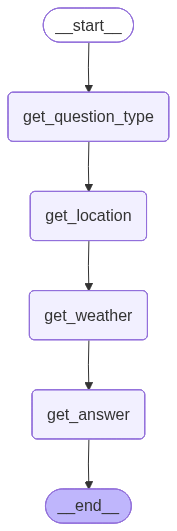

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
answer1 = graph.invoke({"question":"Какая погода будет в Санкт-Петербурге завтра?"})["answer"]
print('---------------')
print(answer1)

get_question_type result: 2
State after get_question_type: {'question': 'Какая погода будет в Санкт-Петербурге завтра?', 'question_kind': 2}
get_location result: Санкт-Петербург
State after get_location: {'question': 'Какая погода будет в Санкт-Петербурге завтра?', 'location': 'Санкт-Петербург'}
State entering get_weather: {'question': 'Какая погода будет в Санкт-Петербурге завтра?', 'location': 'Санкт-Петербург', 'question_kind': 2}
Weather data:  4.9 °C,  Ясно
Full state entering get_answer: {'question': 'Какая погода будет в Санкт-Петербурге завтра?', 'location': 'Санкт-Петербург', 'question_kind': 2, 'weather_data': {'cn': 'Saint Petersburg', 't': 4.9, 'd': 'Ясно'}}
get_answer result: Завтра в Санкт-Петербурге ожидается ясная погода, температура воздуха составит +4,9°C.
---------------
Завтра в Санкт-Петербурге ожидается ясная погода, температура воздуха составит +4,9°C.


In [20]:
answer2 = graph.invoke({"question":"Холодно ли сейчас в Праге?"})["answer"]
print('---------------')
print(answer2)

get_question_type result: 1
State after get_question_type: {'question': 'Холодно ли сейчас в Праге?', 'question_kind': 1}
get_location result: Прага
State after get_location: {'question': 'Холодно ли сейчас в Праге?', 'location': 'Прага'}
State entering get_weather: {'question': 'Холодно ли сейчас в Праге?', 'location': 'Прага', 'question_kind': 1}
Weather data:  10.1 °C,  Преимущественно ясно
Full state entering get_answer: {'question': 'Холодно ли сейчас в Праге?', 'location': 'Прага', 'question_kind': 1, 'weather_data': {'cn': 'Prague', 't': 10.1, 'd': 'Преимущественно ясно'}}
get_answer result: В Праге сейчас +10,1°C, преимущественно ясно.
---------------
В Праге сейчас +10,1°C, преимущественно ясно.


In [21]:
answer3 = graph.invoke({"question":"Сколько человек проживает в Москве?"})["answer"]
print('---------------')
print(answer3)

get_question_type result: 0
State after get_question_type: {'question': 'Сколько человек проживает в Москве?', 'question_kind': 0}
get_location result: Москва
State after get_location: {'question': 'Сколько человек проживает в Москве?', 'location': 'Москва'}
State entering get_weather: {'question': 'Сколько человек проживает в Москве?', 'location': 'Москва', 'question_kind': 0}
Weather data:  12.3 °C,  Облачно с прояснениями
Full state entering get_answer: {'question': 'Сколько человек проживает в Москве?', 'location': 'Москва', 'question_kind': 0, 'weather_data': {'cn': 'Moscow', 't': 12.3, 'd': 'Облачно с прояснениями'}}
get_answer result: ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС
---------------
ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС
